In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.colors as colors
import matplotlib as mpl
import matplotlib.dates as mdates

Figure 1. Predicted near surface permafrost temperature curve

In [2]:
def plot_nine_subplots_simpler(
    u_tensor_1, u_tensor_2, u_tensor_3,
    dt, dz,
    x_positions=[10,20,30,40,50,60,70,80,90],
    depth=0.3, start_date=datetime(2023,7,25),
    shift_days_for_UP1=190,
    shift_days_for_UP2=281,
    df_exp_1=None, df_exp_2=None, df_exp_3=None, df_exp_4=None
):
    # --- 全局样式 ---
    mpl.rcParams['font.family'] = 'Arial'
    #mpl.rcParams['font.size']   = 12

    # --- 构造 PDE 时间轴 ---
    T1, H, W = u_tensor_1.shape
    real_dates_1 = [start_date + timedelta(days=i*dt) for i in range(T1)]
    pde1_idx = {d:i for i,d in enumerate(real_dates_1)}

    T2 = u_tensor_2.shape[0]
    real_dates_2 = [start_date + timedelta(days=i*dt + shift_days_for_UP1) for i in range(T2)]
    pde2_idx = {d:i for i,d in enumerate(real_dates_2)}

    T3 = u_tensor_3.shape[0]
    real_dates_3 = [start_date + timedelta(days=i*dt + shift_days_for_UP2) for i in range(T3)]
    pde3_idx = {d:i for i,d in enumerate(real_dates_3)}

    depth_idx = int(round(depth/dz))

    # --- 阴影分段日期 ---
    year0 = start_date.year if start_date.month<=2 else start_date.year+1
    feb1  = datetime(year0, 2, 1)
    may1  = datetime(year0, 5, 1)
    june1 = datetime(year0, 6, 1)
    left_date, right_date = real_dates_1[0], real_dates_1[-1]

    # --- 实验数据样式 ---
    exp_colors  = ['lightcoral','C1','C0','C2']
    exp_markers = ['o','^','s','d']
    exp_labels  = [
        "Batch 0 (7/25/23 – 1/31/24)",
        "Batch 1 (2/1/24 – 4/30/24)",
        "Batch 2 (5/1/24 – 5/31/24)",
        "Batch 3 (8/1/24 – 8/2/24)"
    ]

    # --- 创建 3×3 子图 ---
    fig, axes = plt.subplots(3,3, figsize=(15,14))
    axes = axes.ravel()

    # PDE 曲线图例句柄
    pde_handles, pde_labels = [], []
    did_pde1 = did_pde2 = did_pde3 = False

    # 实验数据图例句柄
    exp_handles, exp_labels_legend = [], []
    did_plot_exp = [False]*4

    # 小写子图标签
    panel_labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)']

    for i, x_val in enumerate(x_positions):
        ax = axes[i]
        x_idx = int(round(x_val))
        ax.set_xlim(left_date, right_date)

        # 阴影
        ax.axvspan(left_date, feb1,  facecolor='gray',    alpha=0.15, zorder=0)
        ax.axvspan(feb1,     may1,  facecolor='moccasin', alpha=0.15, zorder=0)
        ax.axvspan(may1,     june1, facecolor='skyblue', alpha=0.15, zorder=0)

        # PDE1 (BM)
        p1 = u_tensor_1[:,depth_idx,x_idx].cpu().numpy()
        l1, = ax.plot(real_dates_1, p1, 'k-', lw=1.2)
        if not did_pde1:
            pde_handles.append(l1); pde_labels.append("BM"); did_pde1=True

        # PDE2 (UM1)
        p2 = u_tensor_2[:,depth_idx,x_idx].cpu().numpy()
        l2, = ax.plot(real_dates_2, p2, 'b-.', lw=1.2)
        if not did_pde2:
            pde_handles.append(l2); pde_labels.append("UM1"); did_pde2=True

        # PDE3 (UM2)
        p3 = u_tensor_3[:,depth_idx,x_idx].cpu().numpy()
        l3, = ax.plot(real_dates_3, p3, 'r--', lw=1.2)
        if not did_pde3:
            pde_handles.append(l3); pde_labels.append("UM2"); did_pde3=True

        # 绘制实验数据
        dfs = [df_exp_1, df_exp_2, df_exp_3, df_exp_4]
        exp_dates = [[] for _ in range(4)]
        exp_temps = [[] for _ in range(4)]

        for j, df_exp in enumerate(dfs):
            if df_exp is None: continue
            sub = df_exp[(df_exp.iloc[:,0]==depth)&(df_exp.iloc[:,1]==x_val)]
            if sub.empty: continue
            row = sub.iloc[0]
            for col in df_exp.columns[2:]:
                try: d = datetime.strptime(col, "%m/%d/%Y")
                except: continue
                v = row[col]
                if pd.isna(v): continue
                exp_dates[j].append(d); exp_temps[j].append(v)
            if exp_dates[j]:
                h, = ax.plot(
                    exp_dates[j], exp_temps[j],
                    linestyle='', marker=exp_markers[j],
                    markerfacecolor='white',
                    markeredgecolor=exp_colors[j],
                    markeredgewidth=1.0, ms=8
                )
                if not did_plot_exp[j]:
                    exp_handles.append(h)
                    exp_labels_legend.append(exp_labels[j])
                    did_plot_exp[j] = True

        # 计算并注释 RMSE
        txt = ["RMSE"]
        for j, dates in enumerate(exp_dates):
            if not dates:
                txt.append(f"Batch {j+1}: –")
                continue
            meas = exp_temps[j]
            # BM RMSE
            sb = [int(round((d-start_date).days/dt)) for d in dates]
            preds1 = [p1[k] for k in sb if 0<=k<T1]
            rm1 = np.sqrt(np.mean((np.array(preds1)-np.array(meas))**2)) if preds1 else np.nan
            # UM1 RMSE
            sb2 = [int(round(((d-start_date).days-shift_days_for_UP1)/dt)) for d in dates]
            preds2 = [p2[k] for k in sb2 if 0<=k<T2]
            rm2 = np.sqrt(np.mean((np.array(preds2)-np.array(meas))**2)) if preds2 else np.nan
            # UM2 RMSE for batch 3,4
            if j>=2:
                sb3 = [int(round(((d-start_date).days-shift_days_for_UP2)/dt)) for d in dates]
                preds3 = [p3[k] for k in sb3 if 0<=k<T3]
                rm3 = np.sqrt(np.mean((np.array(preds3)-np.array(meas))**2)) if preds3 else np.nan
                txt.append(f"Batch {j}: BM={rm1:.2f}, UM1={rm2:.2f}, UM2={rm3:.2f}")
            elif j==1:
                txt.append(f"Batch 1: BM={rm1:.2f}, UM1={rm2:.2f}")
            else:
                txt.append(f"Batch 0: BM={rm1:.2f}")

        ax.text(0.02, 0.02, "\n".join(txt),
                transform=ax.transAxes, ha='left', va='bottom',
                fontsize=11, bbox=dict(facecolor='none', alpha=0.5, edgecolor='none'))

        # 标题 & 坐标
        #ax.set_title(f"{panel_labels[i]}  $x$={x_val} m", loc='left')
        ax.set_title(f"$x$={x_val} m", loc='left', fontsize=16)
        ax.set_yticks(np.arange(-35,16,5)); ax.set_ylim(-35,15)
        ax.grid(False)

    # X 轴格式化
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        #for lbl in ax.get_xticklabels():
            #lbl.set_rotation(45)
        ax.tick_params(axis='x', which='major', labelrotation=45, labelsize=12)
        ax.tick_params(axis='y', labelsize=16)
        ax.set_xlabel("Time", fontsize=16)
        ax.set_ylabel("Temperature (°C)", fontsize=16)

    plt.tight_layout()

    # PDE 图例
    if pde_handles:
        fig.legend(pde_handles, pde_labels,
                   loc='lower center', bbox_to_anchor=(0.5,0.11),
                   ncol=len(pde_handles), frameon=False, fontsize=16)

    # 实验数据图例
    if exp_handles:
        fig.legend(exp_handles, exp_labels_legend,
                   loc='lower center', bbox_to_anchor=(0.5,0.09),
                   ncol=len(exp_handles), frameon=False, fontsize=16)

    plt.subplots_adjust(bottom=0.22)
    plt.show()


C:\Users\lygou\AppData\Local\Temp\ipykernel_41640\2567461169.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0        0
1        1
2        2
3        3
4        4
      ... 
399    399
400    400
401    401
402    402
403    403
Name: day_offset, Length: 404, dtype: int64' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_weather.iloc[:,0] = df_weather["day_offset"]


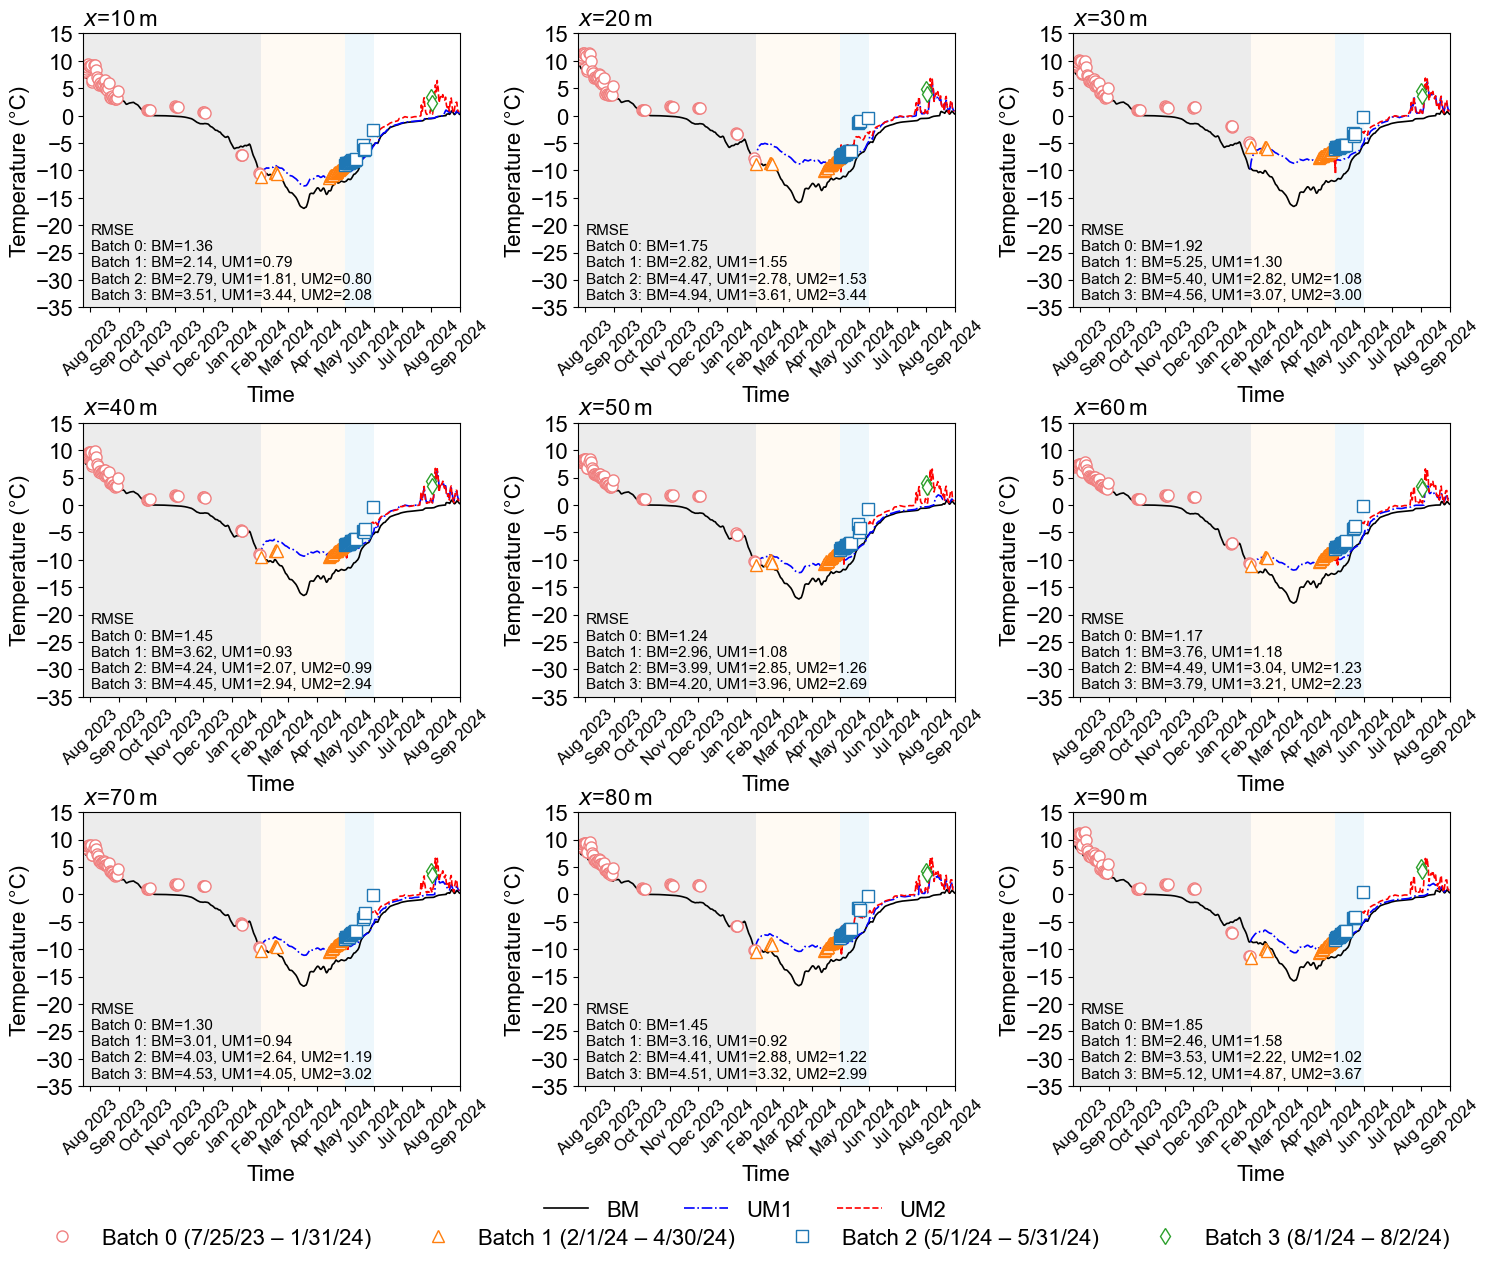

In [3]:
# ------------------------------------------------------Input data-------------------------------------------------------------
# 读取上边界温度
df_weather = pd.read_excel("Data/Upper boundary condition_7_25_2023_8_31_2024.xlsx")
# 读取第一批测试数据
df_exp_1 = pd.read_excel("Data/Observed_data_7_25_2023_1_31_2024.xlsx", header=0)
# 读取第二批测试数据
df_exp_2 = pd.read_excel("Data/Observed_data_2_1_2024_4_30_2024.xlsx", header=0) 
# 读取第三批测试数据
df_exp_3 = pd.read_excel("Data/Observed_data_5_1_2024_5_31_2024.xlsx", header=0)
# 读取第四批测试数据
df_exp_4 = pd.read_excel("Data/Observed_data_8_1_2024_8_2_2024.xlsx", header=0) 


# 读取第一次训练温度分布
u_data_first_train = np.load("Model/u_tensor_baseline_model_forward_varying snow function.npy")  # shape: (T, H, W)
# 读取第二次训练温度分布
u_data_second_train = np.load("Model/u_tensor_UP1_forward.npy")  # shape: (T, H, W)
# 读取第三次训练温度分布
u_data_third_train = np.load("Model/u_tensor_UP2_forward.npy")  # shape: (T, H, W)

# ------------------------------------------------------Figure 1 (temperature curve)------------------------------------------------------------------
start_date = datetime(2023,7,25)
df_weather["Date"] = pd.to_datetime(df_weather.iloc[:,0], format="%m/%d/%Y")
df_weather["day_offset"] = (df_weather["Date"] - start_date).dt.days
# 将第 0 列替换为 day_offset
df_weather.iloc[:,0] = df_weather["day_offset"]
u_tensor_1 = torch.tensor(u_data_first_train, dtype=torch.float32)
u_tensor_2 = torch.tensor(u_data_second_train, dtype=torch.float32)
u_tensor_3 = torch.tensor(u_data_third_train, dtype=torch.float32)
shift_days_for_UP1 = 190
shift_days_for_UP2 = 280

plot_nine_subplots_simpler(
    u_tensor_1,
    u_tensor_2,
    u_tensor_3,
    dt = 0.05, 
    dz = 0.15,
    x_positions=[10,20,30,40,50,60,70,80,90],
    depth=0.3,
    start_date=datetime(2023,7,25),
    shift_days_for_UP1 = shift_days_for_UP1,
    shift_days_for_UP2 = shift_days_for_UP2,
    df_exp_1 = df_exp_1, 
    df_exp_2 = df_exp_2,
    df_exp_3 = df_exp_3,
    df_exp_4 = df_exp_4
    )

Figure 2. Accuracy of the digital twin models

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from datetime import datetime, timedelta
import pandas as pd
import torch

def plot_rmse_boxplot_with_um3(
    u_tensor_1, u_tensor_2, u_tensor_3,  # [T,H,W]
    dt, dz, depth, start_date,
    shift_days_for_UP1, shift_days_for_UP2,
    df_exp_1, df_exp_2, df_exp_3, df_exp_4
):
    # --- 全局字体 ---
    mpl.rcParams['font.family'] = 'Arial'
    mpl.rcParams['font.size']   = 18

    T1, H, W = u_tensor_1.shape
    T2 = u_tensor_2.shape[0]
    T3 = u_tensor_3.shape[0]
    depth_idx = int(round(depth / dz))

    # 批次定义: (df, has_um1, has_um3, period)
    batches = [
        (df_exp_1, False, False, "7/25/23 – 1/31/24"),
        (df_exp_2, True,  False, "2/1/24 – 4/30/24"),
        (df_exp_3, True,  True,  "5/1/24 – 5/31/24"),
        (df_exp_4, True,  True,  "8/1/24 – 8/2/24"),
    ]

    rmse_bm  = []
    rmse_um1 = []
    rmse_um2 = []

    # 计算 RMSE
    for df_exp, has_um1, has_um2, _ in batches:
        if df_exp is None:
            rmse_bm.append([np.nan]*W)
            rmse_um1.append([np.nan]*W)
            rmse_um2.append([np.nan]*W)
            continue

        cols = df_exp.columns[2:]
        bm_list, u1_list, u2_list = [], [], []

        for x in range(W):
            sub = df_exp[(df_exp.iloc[:,0]==depth)&(df_exp.iloc[:,1]==x)]
            if sub.empty:
                bm_list.append(np.nan)
                u1_list.append(np.nan)
                u2_list.append(np.nan)
                continue
            row = sub.iloc[0]
            meas, steps1, steps2, steps3 = [], [], [], []

            for col in cols:
                try:
                    d = datetime.strptime(col, "%m/%d/%Y")
                except:
                    continue
                v = row[col]
                if pd.isna(v):
                    continue
                meas.append(v)
                # BM
                s1 = int(round((d - start_date).days / dt))
                steps1.append(s1)
                # UM1
                if has_um1:
                    s2 = int(round(((d - start_date).days - shift_days_for_UP1) / dt))
                    steps2.append(s2)
                # UM2
                if has_um2:
                    s3 = int(round(((d - start_date).days - shift_days_for_UP2) / dt))
                    steps3.append(s3)

            preds1 = [u_tensor_1[s1,depth_idx,x].item() for s1 in steps1 if 0<=s1<T1]
            rm1 = np.sqrt(np.mean((np.array(preds1)-np.array(meas))**2)) if preds1 else np.nan
            bm_list.append(rm1)

            if has_um1:
                preds2 = [u_tensor_2[s2,depth_idx,x].item() for s2 in steps2 if 0<=s2<T2]
                rm2 = np.sqrt(np.mean((np.array(preds2)-np.array(meas))**2)) if preds2 else np.nan
            else:
                rm2 = np.nan
            u1_list.append(rm2)

            if has_um2:
                preds3 = [u_tensor_3[s3,depth_idx,x].item() for s3 in steps3 if 0<=s3<T3]
                rm3 = np.sqrt(np.mean((np.array(preds3)-np.array(meas))**2)) if preds3 else np.nan
            else:
                rm3 = np.nan
            u2_list.append(rm3)

        rmse_bm.append(bm_list)
        rmse_um1.append(u1_list)
        rmse_um2.append(u2_list)

    # --- 绘制箱型图 ---
    fig, ax = plt.subplots(figsize=(8,9))

    # Science 风格配色
    bm_light  = "#8da0cb"; bm_dark  = "#4d4d90"
    u1_light  = "#fdc086"; u1_dark  = "#e66101"
    u3_light  = "#c7e9b4"; u3_dark  = "#238b45"

    box_width = 0.06
    half      = box_width / 2
    gap       = 0.5
    centers   = [1 + i*gap for i in range(4)]

    data, positions, colors = [], [], []

    # Batch1: BM fitted
    data.append(rmse_bm[0]);  positions.append(centers[0]); colors.append(bm_light)
    # Batch2: BM predicted, UM1 fitted
    data += [rmse_bm[1], rmse_um1[1]]
    positions += [centers[1]-half, centers[1]+half]
    colors += [bm_dark, u1_light]
    # Batch3: BM predicted, UM1 predicted, UM3 fitted
    data += [rmse_bm[2], rmse_um1[2], rmse_um2[2]]
    positions += [centers[2]-box_width, centers[2], centers[2]+box_width]
    colors += [bm_dark, u1_dark, u3_light]
    # Batch4: BM predicted, UM1 predicted, UM3 predicted
    data += [rmse_bm[3], rmse_um1[3], rmse_um2[3]]
    positions += [centers[3]-box_width, centers[3], centers[3]+box_width]
    colors += [bm_dark, u1_dark, u3_dark]

    bplots = ax.boxplot(
        data, positions=positions, widths=box_width,
        patch_artist=True, showfliers=False,
        medianprops={'color':'white','linewidth':2},
        manage_ticks=False
    )
    for patch, col in zip(bplots['boxes'], colors):
        patch.set_facecolor(col)
        patch.set_edgecolor('black')
    
    # --- 打印每个箱体的 Q1, Median, Q3 ---
    for idx, vals in enumerate(data):
        q1, med, q3 = np.nanpercentile(vals, [25, 50, 75])
        print(f"Box {idx+1}: Q1={q1:.3f}, Median={med:.3f}, Q3={q3:.3f}")

    # 设置纵坐标 0–8
    ax.set_ylim(0,8)
    ax.set_yticks(np.arange(0,9,1))
    ax.set_yticks(np.arange(0,8.5,0.5), minor=True)
    ax.yaxis.grid(True, which='major', linestyle=':', alpha=0.5)

    # X 轴标签
    xticks = [f"Batch {i}\n({period})" for i,(_,_,_,period) in enumerate(batches)]
    ax.set_xticks(centers)
    ax.set_xticklabels(xticks, rotation=45, ha='center')
    ax.set_xlabel("Data batch and time period")
    ax.set_ylabel("RMSE (°C)")

    # 图例：三列，每列一个模型，拟合在上预测在下
    legend_elems = [
        mpatches.Patch(facecolor=bm_light, label='BM fitting'),
        mpatches.Patch(facecolor=bm_dark,  label='BM prediction'),
        mpatches.Patch(facecolor=u1_light, label='UM1 fitting'),
        mpatches.Patch(facecolor=u1_dark,  label='UM1 prediction'),
        mpatches.Patch(facecolor=u3_light, label='UM2 fitting'),
        mpatches.Patch(facecolor=u3_dark,  label='UM2 prediction'),
    ]
    ax.legend(
        handles=legend_elems,
        loc='upper center',
        fontsize=14,           # 缩小字体
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 0.92)  # 放到图幅内部靠上位置
    )

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)  # 给图例留点空间
    plt.show()


Box 1: Q1=1.305, Median=1.530, Q3=1.855
Box 2: Q1=2.501, Median=3.064, Q3=3.754
Box 3: Q1=0.934, Median=1.102, Q3=1.499
Box 4: Q1=3.589, Median=4.182, Q3=4.498
Box 5: Q1=2.265, Median=2.634, Q3=2.858
Box 6: Q1=1.020, Median=1.115, Q3=1.220
Box 7: Q1=4.020, Median=4.451, Q3=4.728
Box 8: Q1=3.171, Median=3.606, Q3=4.246
Box 9: Q1=2.568, Median=2.937, Q3=3.240


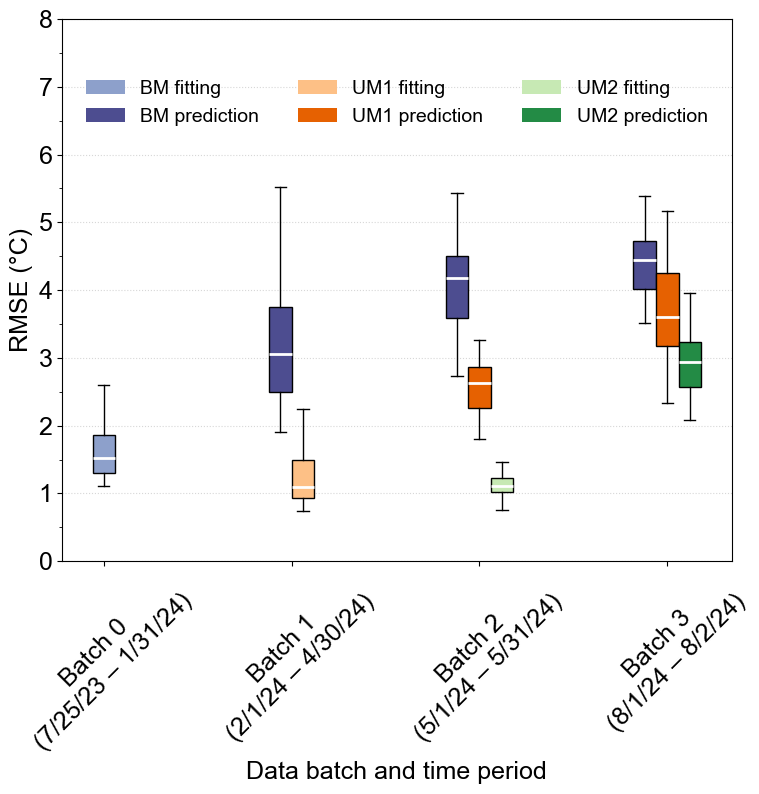

In [5]:
dz = 0.15
dt = 0.05
depth = 0.3

plot_rmse_boxplot_with_um3(
    u_tensor_1, u_tensor_2, u_tensor_3,  # [T,H,W]
    dt, dz, depth, start_date,
    shift_days_for_UP1, shift_days_for_UP2,
    df_exp_1, df_exp_2, df_exp_3, df_exp_4
)